In [1]:
# loading the dataset and viewing first 5 rows
import pandas as pd
df = pd.read_csv(r"C:\Users\USER\Desktop\Machine Learning\Projects\ai_assistant_usage_student_life.csv")
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [2]:
# dataset shape
df.shape

(10000, 11)

In [3]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


In [4]:
# check for missing values
df.isnull().sum()
# there are no missing values

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

In [5]:
# summary statistics for 'totalprompts' and 'sessionlengthmin'
df[["SessionLengthMin", "TotalPrompts"]].describe()

,SessionLengthMin,TotalPrompts
count,10000.000000,10000.000000
mean,19.846467,5.607500
std,13.897302,4.648764
min,0.030000,1.000000
25%,9.630000,2.000000
50%,16.650000,4.000000
75%,26.670000,8.000000
max,110.810000,39.000000


In [6]:
# unique values in specific columns
unique_counts = df[["StudentLevel", "Discipline", "TaskType"]].nunique() #nunique counts unique values
print(unique_counts)

StudentLevel    3
Discipline      7
TaskType        6
dtype: int64


In [7]:
#most common task type
df["TaskType"].value_counts()

TaskType
Writing          3101
Studying         2040
Homework Help    1959
Coding           1948
Brainstorming     476
Research          476
Name: count, dtype: int64

In [8]:
# average sessionlengthmin for each studentlevel
df.groupby("StudentLevel")["SessionLengthMin"].mean()

StudentLevel
Graduate         20.252236
High School      20.023740
Undergraduate    19.650943
Name: SessionLengthMin, dtype: float64

#### Visualization

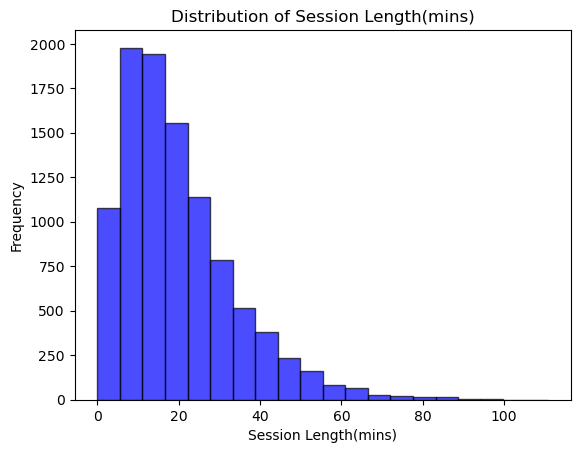

In [9]:
# histogram of sessionlengthmin
import matplotlib.pyplot as plt
plt.hist(df["SessionLengthMin"], bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title("Distribution of Session Length(mins)")
plt.xlabel("Session Length(mins)")
plt.ylabel("Frequency")
plt.show()
# alpha controls the transparency of the bars,the higher the value, the more opaque the bars

#### Interpretation
- the histogram is skewed to the left
- most sessions are short, between 5 - 25 mins
- very few sessions are long, above 50 mins representing outliers 
- as session length increases the frequency drops
- most users prefer short interactions with AI assistant, probably for quick tasks or queries and a small fraction use it for extended sessions probably for studying or long projects.

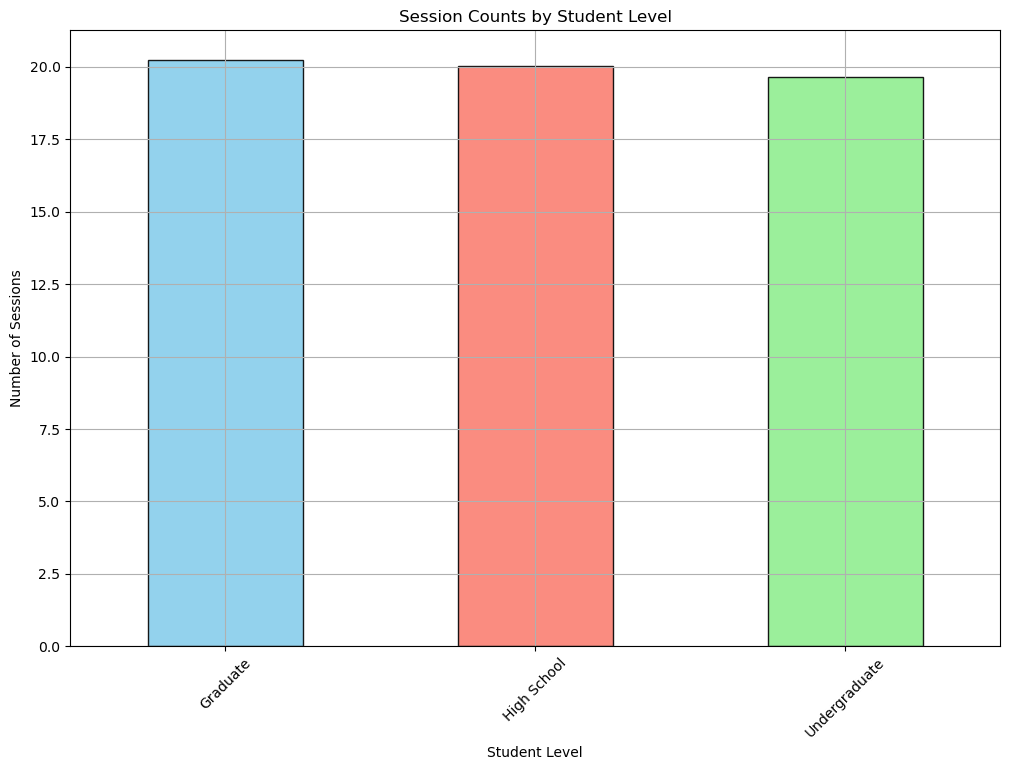

In [10]:
# bar chart of session counts by student level
session_counts = df.groupby("StudentLevel")["SessionLengthMin"].mean()
plt.figure(figsize=(12,8))
session_counts.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"], edgecolor="black", alpha=0.9)
plt.title("Session Counts by Student Level")
plt.xlabel("Student Level")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


#### Interpretation
- Undergraduate students have the highest number of sessions, around 6000. Thus they are the primary users of AI assistant.
- High school and graduate students session count is around 2000. These two sets engage less frequently with AI assistant.
- AI assistant is more appealing to undergraduate students who seem to have more academic needs suited for using this tool.

C:\Users\USER\AppData\Local\Temp\ipykernel_11788\533183077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="TaskType", palette="viridis")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Studying'),
  Text(1, 0, 'Coding'),
  Text(2, 0, 'Writing'),
  Text(3, 0, 'Brainstorming'),
  Text(4, 0, 'Homework Help'),
  Text(5, 0, 'Research')])

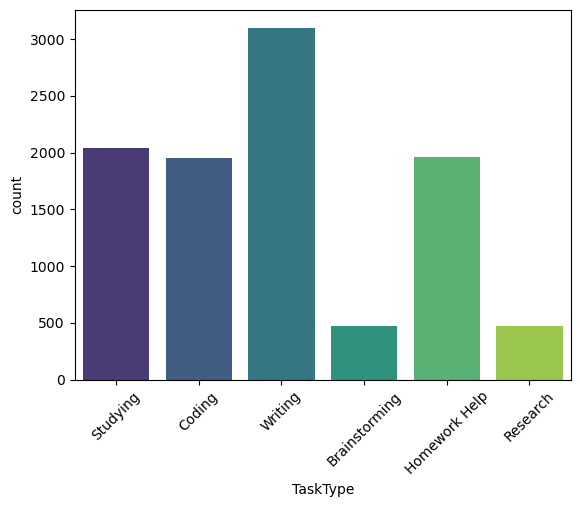

In [11]:
# countplot of tasktype using seaorn
import seaborn as sns
sns.countplot(data=df, x="TaskType", palette="viridis")
plt.xticks(rotation=45)

C:\Users\USER\AppData\Local\Temp\ipykernel_11788\3150204905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="StudentLevel", y="SessionLengthMin", palette="coolwarm")


Text(0, 0.5, 'Session Length (Minutes)')

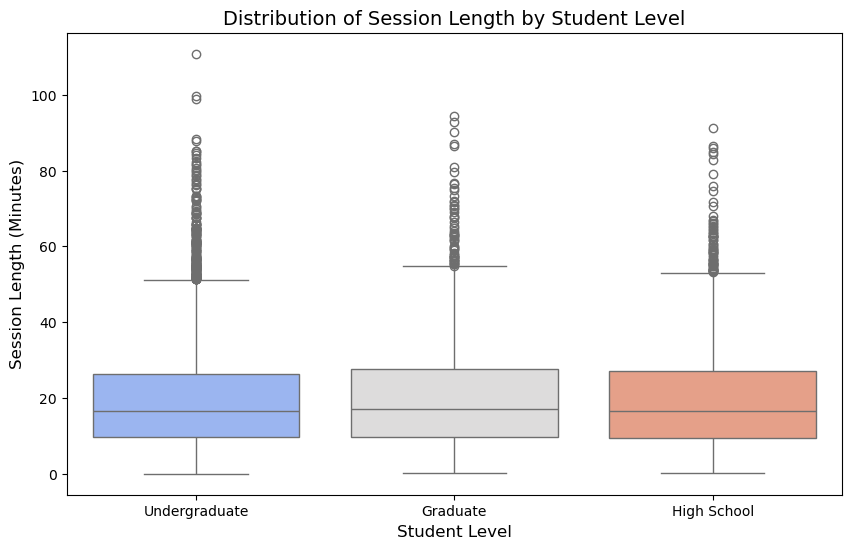

In [12]:
# boxplot of sessionlengthmin grouped by student level
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="StudentLevel", y="SessionLengthMin", palette="coolwarm")
plt.title("Distribution of Session Length by Student Level", fontsize=14)
plt.xlabel("Student Level", fontsize=12)
plt.ylabel("Session Length (Minutes)", fontsize=12)

#### Interpretation
- box(IQR): shows the middle 50% of the session length that averages 15-25 mins for all student levels
- The median represented by the line in the box is approximately at the 18 min mark for all student levels showing that most students spend averagely 18 mins using the AI assistant
- There are outliers at all student levels revealing that some students use the AI assistant for longer sessions,perhaps on projects

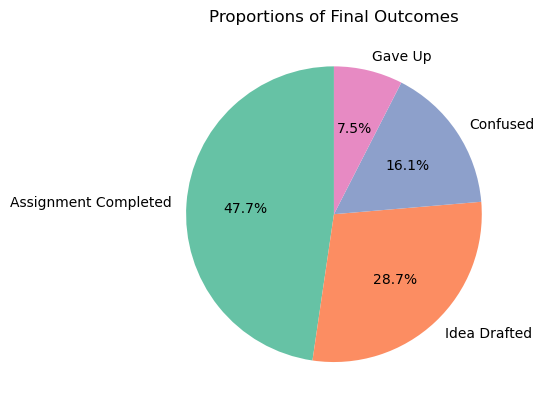

In [13]:
# pie chart of proportions of final outcomes
df["FinalOutcome"].value_counts().plot(kind="pie", autopct='%1.1f%%', startangle=90, colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"])
plt.title("Proportions of Final Outcomes")
plt.ylabel("")
plt.show()

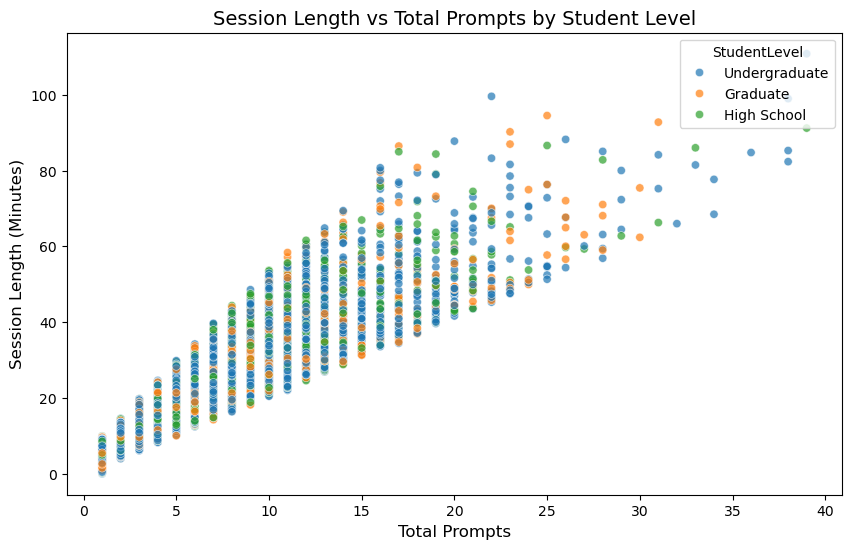

In [14]:
# scatterplot of sessionlengthmin vs totalprompts
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="TotalPrompts", y="SessionLengthMin", hue="StudentLevel", alpha=0.7)
plt.title("Session Length vs Total Prompts by Student Level", fontsize=14)
plt.xlabel("Total Prompts", fontsize=12)
plt.ylabel("Session Length (Minutes)", fontsize=12)
plt.legend(title="StudentLevel", loc="upper right")
plt.show()

#### Interpretation
- a)There is a positive correlation and as the number of prompts increase the session length also increases. 
- b)The scatter points form an upward triangular band so students who use few prompts(0-5) almost always have short sessions(0-20 mins) and students who use many prompts(15-40) have longer sessions of about 40-100 mins
- c)Undergraduates appear consistently spread across all prompt ranges showing balanced usage.
- Graduates are slightly more spread out at higher prompt counts showing they use the AI assistant in sometimes longer and more intensive sessions.
- High school cluster more tightly especially in the mid range(5-20 and 20-60) indicating moderate use
d)A few graduate and undergraduate points show high session lengths(>90 mins) even for fewer prompts which could be due to slower usage pace or leaving sessions open
- only a handful of students reach 30-40 prompts and these are likely heavy or advanced users

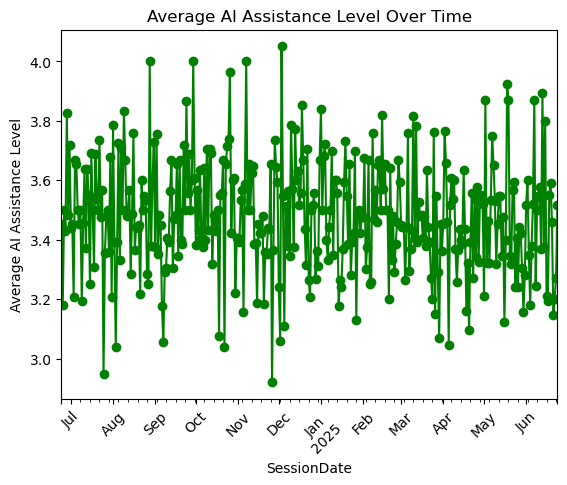

In [15]:
# line chart of average ai assistance level over session date
df["SessionDate"] = pd.to_datetime(df["SessionDate"])
df.groupby("SessionDate")["AI_AssistanceLevel"].mean().plot(kind="line", color="green", marker="o")
plt.title("Average AI Assistance Level Over Time")
plt.xlabel("SessionDate")
plt.ylabel("Average AI Assistance Level")
plt.xticks(rotation=45)
plt.show()

#### Interpretation
- Values fluctuate heavily day-to-day, but the overall average hovers around 3.3-3.6 consistently throughout the year
- Users consistently use AI assitance at a moderate to high level and seasonal or monthly trends are not strongly visible

In [16]:
df.dtypes

SessionID                     object
StudentLevel                  object
Discipline                    object
SessionDate           datetime64[ns]
SessionLengthMin             float64
TotalPrompts                   int64
TaskType                      object
AI_AssistanceLevel             int64
FinalOutcome                  object
UsedAgain                       bool
SatisfactionRating           float64
dtype: object

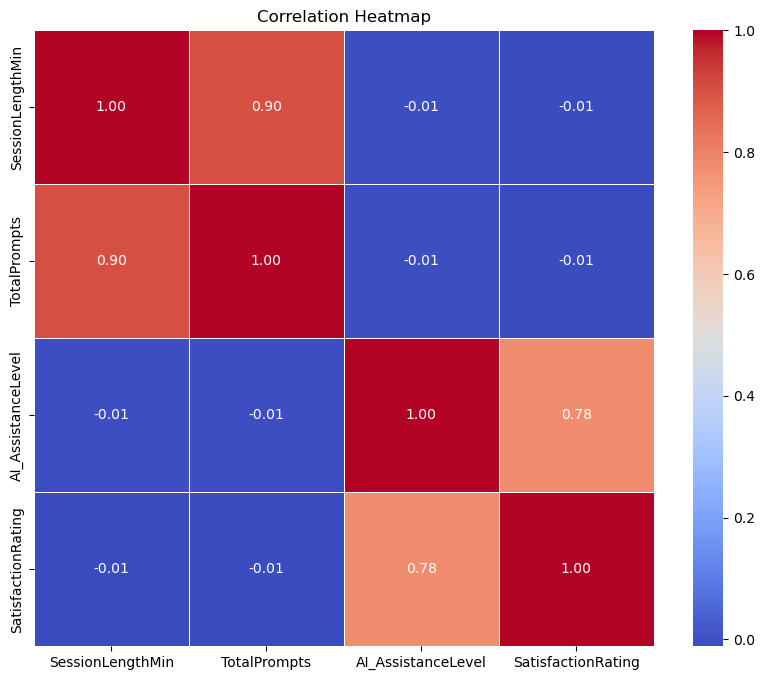

In [17]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Heatmap of correlation among numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [18]:
# average sessionlengthmin for each tasktype
df.groupby("TaskType")["SessionLengthMin"].mean()

TaskType
Brainstorming    21.964223
Coding           19.467659
Homework Help    19.940536
Research         20.410000
Studying         19.705917
Writing          19.705888
Name: SessionLengthMin, dtype: float64

In [19]:
# discipline with the most sessions
df["Discipline"].value_counts().idxmax()

'Biology'

    StudentLevel  AI_AssistanceLevel
0       Graduate            3.469674
1    High School            3.477060
2  Undergraduate            3.483607


C:\Users\USER\AppData\Local\Temp\ipykernel_11788\2490934101.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="StudentLevel", y="AI_AssistanceLevel", data=avg_assistance, palette="coolwarm")


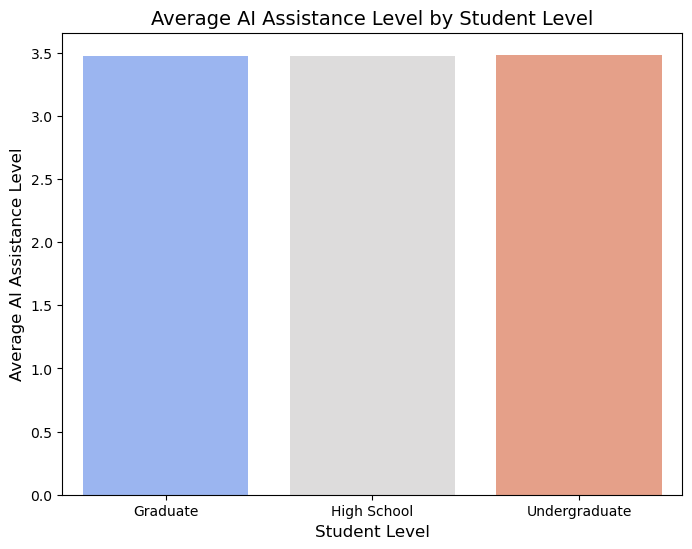

In [20]:
# average ai assistance level vs student level
avg_assistance = df.groupby("StudentLevel")["AI_AssistanceLevel"].mean().reset_index()

print(avg_assistance)

# Plot as bar chart
plt.figure(figsize=(8,6))
sns.barplot(x="StudentLevel", y="AI_AssistanceLevel", data=avg_assistance, palette="coolwarm")

plt.title("Average AI Assistance Level by Student Level", fontsize=14)
plt.xlabel("Student Level", fontsize=12)
plt.ylabel("Average AI Assistance Level", fontsize=12)

plt.show()


In [21]:
# most common final outcome for graduate students
graduate_outcomes = df[df["StudentLevel"] == "Graduate"]["FinalOutcome"].value_counts()
most_common_outcome = graduate_outcomes.idxmax()
print(f"The most common final outcome for graduate students is: {most_common_outcome}")
plt.show()

The most common final outcome for graduate students is: Assignment Completed


In [22]:
# median sessionlengthmin for each finaloutcome
median_session_length = df.groupby("FinalOutcome")["SessionLengthMin"].median().reset_index()
print(median_session_length)

           FinalOutcome  SessionLengthMin
0  Assignment Completed            16.570
1              Confused            16.040
2               Gave Up            17.290
3          Idea Drafted            17.085


#### Feature Engineering and Encoding

In [23]:
# convert session date to year, month and day
df["SessionDate"] = pd.to_datetime(df["SessionDate"])
df["SessionYear"] = df["SessionDate"].dt.year
df["SessionMonth"] = df["SessionDate"].dt.month
df["SessionDay"] = df["SessionDate"].dt.day

In [24]:
# encode student level using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["StudentLevel"] = label_encoder.fit_transform(df["StudentLevel"])

In [25]:
# apply one hot encoding to task type
df = pd.get_dummies(df, columns=["TaskType"], drop_first=True)

In [26]:
# creating a new feature
prompts_per_minute = df["TotalPrompts"]/df["SessionLengthMin"]

In [27]:
# bin sessionlengthmin to short, medium, long categories
import numpy as np
bins = [0, 30, 60, np.inf]
labels = ["Short", "Medium", "Long"]
df["SessionLengthCategory"] = pd.cut(df["SessionLengthMin"], bins=bins, labels=labels, right=False)

#### Machine Learning (classification models)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SessionID               10000 non-null  object        
 1   StudentLevel            10000 non-null  int64         
 2   Discipline              10000 non-null  object        
 3   SessionDate             10000 non-null  datetime64[ns]
 4   SessionLengthMin        10000 non-null  float64       
 5   TotalPrompts            10000 non-null  int64         
 6   AI_AssistanceLevel      10000 non-null  int64         
 7   FinalOutcome            10000 non-null  object        
 8   UsedAgain               10000 non-null  bool          
 9   SatisfactionRating      10000 non-null  float64       
 10  SessionYear             10000 non-null  int32         
 11  SessionMonth            10000 non-null  int32         
 12  SessionDay              10000 non-null  int32  

In [29]:
# 1.predicting final outcome using decision tree
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2.define features and target
x = df.drop(columns = ["FinalOutcome", "SessionID", "SessionDate"]) #drop all columns except finaloutcome
y = df["FinalOutcome"] # target
# SessionId and SessionDate are dropped since decision tree model can't handle datetime types

# 3.convert categorical columns to numeric
x = pd.get_dummies(x, drop_first=True)

# 4.split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 5.train decision tree
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

# 6.make predictions
y_pred = model.predict(x_test)

# 7. evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.374

Classification Report:
                       precision    recall  f1-score   support

Assignment Completed       0.50      0.48      0.49       930
            Confused       0.26      0.26      0.26       349
             Gave Up       0.12      0.12      0.12       170
        Idea Drafted       0.31      0.34      0.33       551

            accuracy                           0.37      2000
           macro avg       0.30      0.30      0.30      2000
        weighted avg       0.38      0.37      0.38      2000


Confusion Matrix:
 [[449 140  64 277]
 [131  90  38  90]
 [ 64  41  20  45]
 [247  74  41 189]]


In [30]:
# predict usedagain using logistic regression
# import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# define features(x) and target(y)
x = df.drop(columns= ["UsedAgain", "SessionID", "SessionDate"]) #predictors
y = df["UsedAgain"] #target

# convert categorical columns to numeric
x = pd.get_dummies(x, drop_first=True)

#split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures that the proportion of classes in the target variable is maintained in both training and testing sets

# train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(x_train, y_train)

# make predictions
y_pred_1 = logreg.predict(x_test)

# evaluation
accuracy = accuracy_score(y_test, y_pred_1)
print("Accuracy", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_1))

Accuracy 0.7425

Classification Report:
               precision    recall  f1-score   support

       False       0.58      0.47      0.52       587
        True       0.79      0.86      0.82      1413

    accuracy                           0.74      2000
   macro avg       0.69      0.66      0.67      2000
weighted avg       0.73      0.74      0.73      2000


Confusion Matrix:
 [[ 274  313]
 [ 202 1211]]


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# predict finaloutcome using random forest
# import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# define features and targets
x = df.drop(columns=["FinalOutcome", "SessionID", "SessionDate"]) 
y = df["FinalOutcome"]

#convert categorical columns to numerical
x = pd.get_dummies(x, drop_first=True) #drop_first=True to avoid dummy variable trap

# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# train the model
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, class_weight="balanced")
rf.fit(x_train, y_train)

#predictions
y_pred = rf.predict(x_test)

# evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.466

Classification Report:
                       precision    recall  f1-score   support

Assignment Completed       0.52      0.76      0.62       953
            Confused       0.36      0.27      0.31       323
             Gave Up       0.22      0.04      0.07       151
        Idea Drafted       0.35      0.20      0.26       573

            accuracy                           0.47      2000
           macro avg       0.36      0.32      0.31      2000
        weighted avg       0.42      0.47      0.42      2000


Confusion Matrix:
 [[723  77   4 149]
 [183  87  12  41]
 [ 74  43   6  28]
 [414  38   5 116]]


In [32]:
# using KNN to clasify usedagain
# import libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# define features and target
x = df.drop(columns=["UsedAgain", "SessionID", "SessionDate"])
y = df["UsedAgain"]

#convert categorical columns to numerical
x = pd.get_dummies(x, drop_first=True) #drop_first=True to avoid dummy variable trap

# split into training and testing set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

# standardize the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# initialize and train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_test_scaled, y_test)

# make predictions
y_pred = knn.predict(x_test_scaled)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.7765

Classification Report:
               precision    recall  f1-score   support

       False       0.70      0.42      0.52       587
        True       0.79      0.93      0.85      1413

    accuracy                           0.78      2000
   macro avg       0.75      0.67      0.69      2000
weighted avg       0.77      0.78      0.76      2000


Confusion Matrix:
 [[ 245  342]
 [ 105 1308]]


In [33]:
# using naive bayes to classify finaloutcome
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# features and target
x = pd.get_dummies(df.drop(columns=["FinalOutcome", "SessionID", "SessionDate"]), drop_first=True)
y = df["FinalOutcome"]

# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# standardize the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# train naive bayes model
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)

# make predictions
y_pred = gnb.predict(x_test_scaled)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.4795

Classification Report:
                       precision    recall  f1-score   support

Assignment Completed       0.52      0.84      0.65       953
            Confused       0.39      0.27      0.32       323
             Gave Up       0.16      0.11      0.13       151
        Idea Drafted       0.36      0.09      0.15       573

            accuracy                           0.48      2000
           macro avg       0.36      0.33      0.31      2000
        weighted avg       0.43      0.48      0.41      2000


Confusion Matrix:
 [[804  54  35  60]
 [189  86  26  22]
 [ 81  42  16  12]
 [462  38  20  53]]


In [34]:
# gradient boosting classifier for used again
# import libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# features and target
x = pd.get_dummies(df.drop(columns=["UsedAgain", "SessionID", "SessionDate"]), drop_first=True)
y = df["UsedAgain"]

# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# train the model
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(x_train_scaled, y_train)

# predictions
y_pred = gbc.predict(x_test_scaled)

# evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.744

Classification Report:
               precision    recall  f1-score   support

       False       0.59      0.44      0.50       587
        True       0.79      0.87      0.83      1413

    accuracy                           0.74      2000
   macro avg       0.69      0.65      0.66      2000
weighted avg       0.73      0.74      0.73      2000


Confusion Matrix:
 [[ 256  331]
 [ 181 1232]]


In [35]:
# applying xgboost on finaloutcome
# import libraries

!pip install xgboost
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# features and target
x = pd.get_dummies(df.drop(columns=["FinalOutcome", "SessionID", "SessionDate"]), drop_first=True)
y = df["FinalOutcome"]

# split the data 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# standardize the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# encode target values (FinalOutcome )
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# train the model
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(x_train_scaled, y_train_enc)

# make predictions
y_pred_enc = xgb.predict(x_test_scaled)

# decode predictions back to original labels
y_pred = le.inverse_transform(y_pred_enc)
y_test_decoded = le.inverse_transform(y_test_enc)

# evaluate the model
accuracy = accuracy_score(y_test_decoded, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:54:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.4875

Classification Report:
                       precision    recall  f1-score   support

Assignment Completed       0.53      0.84      0.65       953
            Confused       0.37      0.30      0.33       323
             Gave Up       0.29      0.01      0.03       151
        Idea Drafted       0.36      0.12      0.18       573

            accuracy                           0.49      2000
           macro avg       0.38      0.32      0.30      2000
        weighted avg       0.43      0.49      0.42      2000


Confusion Matrix:
 [[805  75   1  72]
 [183  98   4  38]
 [ 80  52   2  17]
 [460  43   0  70]]


In [36]:
# split dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", x_train.shape[0])
print("Testing set size:", x_test.shape[0])

Training set size: 8000
Testing set size: 2000


In [37]:
# evaluate xgboost using accuracy and confusion matrix
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# train the model
model = XGBClassifier(n_estimators=100,
                      learning_rate=0.1,
                      max_depth=3,
                      random_state=42,
                      eval_metric='mlogloss')
model.fit(x_train, y_train)

# make predictions
y_pred = model.predict(x_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Accuracy: 0.4875
Confusion Matrix:
 [[805  75   1  72]
 [183  98   4  38]
 [ 80  52   2  17]
 [460  43   0  70]]


In [39]:
# generating a classification report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# train the model
model = XGBClassifier(n_estimators=100,
                    learning_rate=0.1,
                    max_depth=3,
                    random_state=42,
                    eval_metric='mlogloss')
model.fit(x_train, y_train)

# predictions
y_pred = model.predict(x_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# classification report
report = classification_report(y_test, y_pred, target_names=le.classes_)
print("Classification Report:\n", report)




Accuracy: 0.4875
Confusion Matrix:
 [[805  75   1  72]
 [183  98   4  38]
 [ 80  52   2  17]
 [460  43   0  70]]
Classification Report:
                       precision    recall  f1-score   support

Assignment Completed       0.53      0.84      0.65       953
            Confused       0.37      0.30      0.33       323
             Gave Up       0.29      0.01      0.03       151
        Idea Drafted       0.36      0.12      0.18       573

            accuracy                           0.49      2000
           macro avg       0.38      0.32      0.30      2000
        weighted avg       0.43      0.49      0.42      2000



In [43]:
# performing cross validation for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# initialize logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# perform 5-fold cross-validation
cv_scores = cross_val_score(logreg, x, y_encoded, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())
print ("Standard deviation:", cv_scores.std())

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

Cross-validation scores: [0.4985 0.499  0.488  0.486  0.48  ]
Mean cross-validation score: 0.49030000000000007
Standard deviation: 0.007386474125047762


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
# hyperparameter tuning using grid search for decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# initialize decision tree model
dt = DecisionTreeClassifier(random_state=42)

# define hyperparameter grid
param_grid = {
    'max_depth': [None, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ["gini", "entropy", "log_loss"]
}

# gridsearchcv setup
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# fit gridsearchcv
grid_search.fit(x, y_encoded)

# best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# best model
best_dt = grid_search.best_estimator_

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-validation Accuracy: 0.4976


In [45]:
# random forest tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# initialize random forest
rf = RandomForestClassifier(random_state=42)

# define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20]
}

#gridsearchcv setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# fit gridsearchcv
grid_search.fit(x, y_encoded)

# best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

# best model from gridsearch
best_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Cross Validation Accuracy: 0.48929999999999996


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# features and target
x = pd.get_dummies(df.drop(columns=["UsedAgain", "SessionID", "SessionDate"]), drop_first=True)
y = df["UsedAgain"]

# Encode Target Variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize Features (for KNN & Logistic Regression)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train, Predict, Evaluate
results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:  # use scaled data
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:  # use raw data
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })

# Results Table
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)    

c:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:11:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Accuracy  Precision  Recall  F1-Score
5    Gradient Boosting    0.7440   0.728819  0.7440  0.731702
0  Logistic Regression    0.7425   0.730346  0.7425  0.733922
2        Random Forest    0.7370   0.715195  0.7370  0.712950
3          Naive Bayes    0.7245   0.717112  0.7245  0.720194
6              XGBoost    0.7180   0.692505  0.7180  0.695109
4                  KNN    0.7050   0.679101  0.7050  0.684461
1        Decision Tree    0.6240   0.624748  0.6240  0.624372
